In [1]:
# ============================================
# PASO 1: CARGA DEL DATASET
# Cargamos el dataset de precios de casas
# directamente con pandas desde la carpeta raw
# ============================================

import pandas as pd

df = pd.read_csv("C:/Users/pc/repaso_ciencia/repaso-ciencia/data/01_raw/Housing.csv")

# Verificamos las primeras filas para confirmar la carga
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [2]:
# ============================================
# PASO 2: EXPLORACIÓN INICIAL
# Revisamos el tamaño, tipos de datos y
# valores nulos para entender el dataset
# ============================================

# Tamaño del dataset
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

# Tipos de datos por columna
print("\nTipos de datos:")
print(df.dtypes)

# Verificación de valores nulos
print("\nValores nulos por columna:")
print(df.isnull().sum())

Filas: 545
Columnas: 13

Tipos de datos:
price               int64
area                int64
bedrooms            int64
bathrooms           int64
stories             int64
mainroad              str
guestroom             str
basement              str
hotwaterheating       str
airconditioning       str
parking             int64
prefarea              str
furnishingstatus      str
dtype: object

Valores nulos por columna:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [3]:
# ============================================
# PASO 3: CODIFICACIÓN BINARIA
# Convertimos columnas yes/no a 1/0
# porque los modelos de ML no entienden texto
# ============================================

columnas_binarias = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 
                     'airconditioning', 'prefarea']

df[columnas_binarias] = df[columnas_binarias].apply(lambda x: x.map({'yes': 1, 'no': 0}))

# Verificamos que la conversión fue correcta
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished


In [4]:
# ============================================
# PASO 4: ONE-HOT ENCODING
# Convertimos furnishingstatus a columnas binarias
# porque tiene 3 valores y no tiene orden lógico
# entre ellos (no es mejor ser furnished que unfurnished)
# ============================================

df = pd.get_dummies(df, columns=['furnishingstatus'])

# Convertimos True/False a 1/0 para consistencia
df[['furnishingstatus_furnished', 'furnishingstatus_semi-furnished', 
    'furnishingstatus_unfurnished']] = df[['furnishingstatus_furnished', 
    'furnishingstatus_semi-furnished', 
    'furnishingstatus_unfurnished']].astype(int)

# Verificamos las nuevas columnas
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,1,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,0,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,1,0,0


In [5]:
# ============================================
# PASO 5: NORMALIZACIÓN (MinMax)
# Escalamos los valores numéricos entre 0 y 1
# para que ninguna variable domine por su magnitud
# ============================================

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

columnas_numericas = ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']

df[columnas_numericas] = scaler.fit_transform(df[columnas_numericas])

# Verificamos que los valores están entre 0 y 1
df[columnas_numericas].describe()

,price,area,bedrooms,bathrooms,stories,parking
count,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000
mean,0.261189,0.240587,0.393028,0.095413,0.268502,0.231193
std,0.161943,0.149151,0.147613,0.167490,0.289164,0.287195
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.145455,0.134021,0.200000,0.000000,0.000000,0.000000
50%,0.224242,0.202749,0.400000,0.000000,0.333333,0.000000
75%,0.345455,0.323711,0.400000,0.333333,0.333333,0.333333
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [6]:
# ============================================
# PASO 6: ESTANDARIZACIÓN (StandardScaler)
# Centramos los datos alrededor de 0 con
# desviación estándar de 1, útil para
# algoritmos como regresión lineal
# ============================================

from sklearn.preprocessing import StandardScaler

scaler_std = StandardScaler()

df_std = df.copy()
df_std[columnas_numericas] = scaler_std.fit_transform(df[columnas_numericas])

# Verificamos que la media es cercana a 0
df_std[columnas_numericas].describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,5.450000e+02,5.450000e+02,5.450000e+02,5.450000e+02
mean,1.042999e-16,0.000000,-2.607496e-16,-2.607496e-17,2.607496e-16,-1.042999e-16
std,1.000919e+00,1.000919,1.000919e+00,1.000919e+00,1.000919e+00,1.000919e+00
min,-1.614327e+00,-1.614530,-2.665004e+00,-5.701867e-01,-9.293967e-01,-8.057412e-01
25%,-7.153170e-01,-0.715145,-1.308863e+00,-5.701867e-01,-9.293967e-01,-8.057412e-01
50%,-2.283534e-01,-0.253922,4.727831e-02,-5.701867e-01,2.244101e-01,-8.057412e-01
75%,5.208214e-01,0.557830,4.727831e-02,1.421812e+00,2.244101e-01,3.559756e-01
max,4.566365e+00,5.096263,4.115701e+00,5.405809e+00,2.532024e+00,2.679409e+00


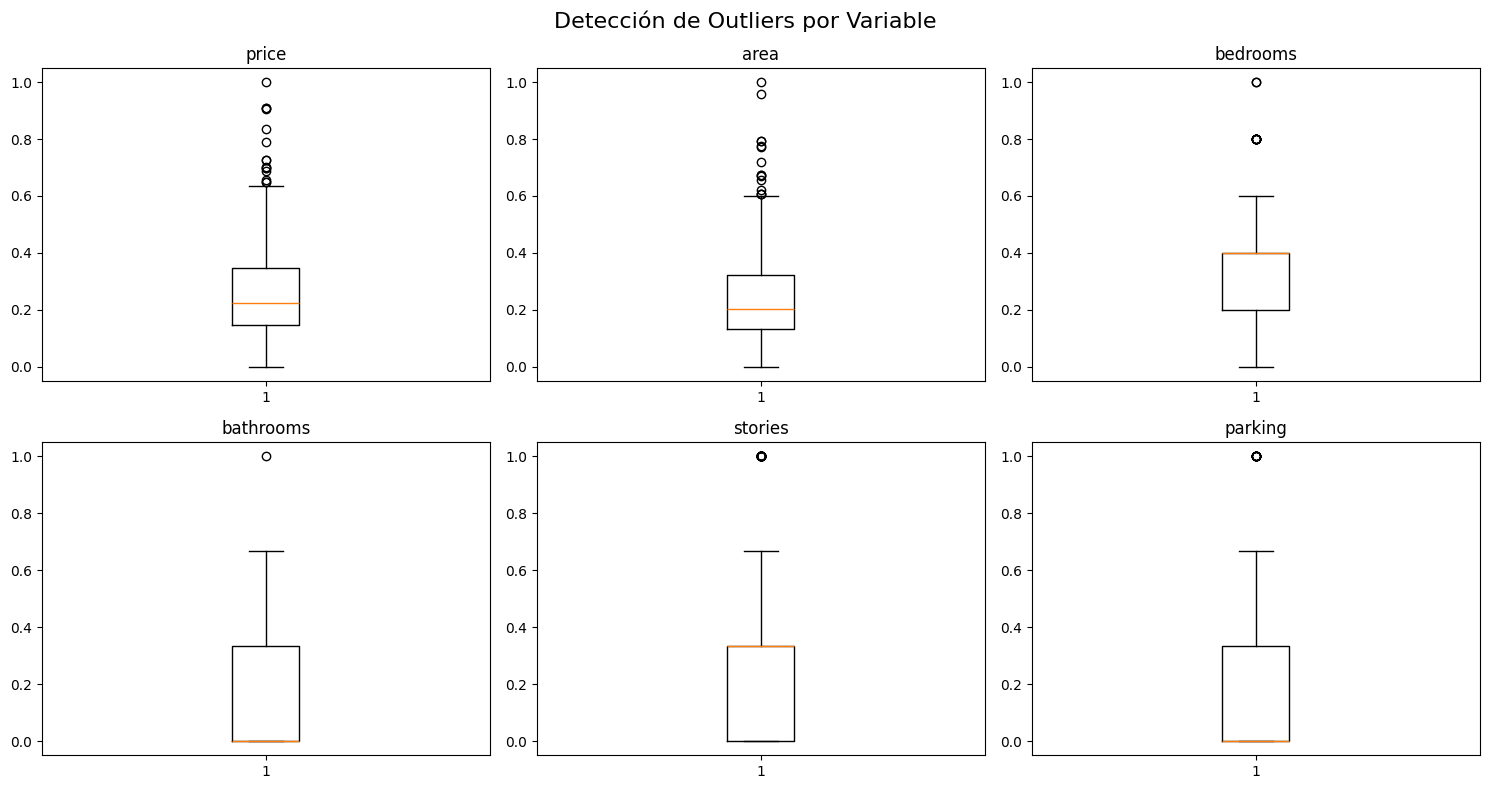

In [7]:
# ============================================
# PASO 7: DETECCIÓN DE OUTLIERS
# Visualizamos los valores atípicos usando
# boxplots para cada variable numérica
# ============================================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(columnas_numericas):
    axes[i].boxplot(df[col])
    axes[i].set_title(col)

plt.suptitle("Detección de Outliers por Variable", fontsize=16)
plt.tight_layout()
plt.show()

In [8]:
# ============================================
# PASO 8: ELIMINACIÓN DE OUTLIERS (IQR)
# Eliminamos valores atípicos usando el método
# IQR (Rango Intercuartílico). Se eliminan los
# valores que están 1.5 veces fuera del rango
# entre Q1 y Q3
# ============================================

df_limpio = df.copy()

for col in columnas_numericas:
    Q1 = df_limpio[col].quantile(0.25)
    Q3 = df_limpio[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    df_limpio = df_limpio[(df_limpio[col] >= limite_inferior) & 
                          (df_limpio[col] <= limite_superior)]

print(f"Filas originales: {df.shape[0]}")
print(f"Filas después de eliminar outliers: {df_limpio.shape[0]}")
print(f"Outliers eliminados: {df.shape[0] - df_limpio.shape[0]}")

Filas originales: 545
Filas después de eliminar outliers: 365
Outliers eliminados: 180


In [9]:
# ============================================
# PASO 9: FEATURE ENGINEERING
# Creamos nuevas variables a partir de las
# existentes para darle más información al modelo
# - precio_por_area: eficiencia del precio
# - total_habitaciones: suma de dormitorios y baños
# - indice_lujo: suma de comodidades del inmueble
# ============================================

df_limpio = df_limpio.copy()

# Ratio de precio por área
df_limpio['precio_por_area'] = df_limpio['price'] / df_limpio['area']

# Total de habitaciones
df_limpio['total_habitaciones'] = df_limpio['bedrooms'] + df_limpio['bathrooms']

# Índice de lujo
df_limpio['indice_lujo'] = (df_limpio['mainroad'] + df_limpio['guestroom'] + 
                            df_limpio['basement'] + df_limpio['airconditioning'] + 
                            df_limpio['prefarea'])

print(df_limpio[['precio_por_area', 'total_habitaciones', 'indice_lujo']].head())

    precio_por_area  total_habitaciones  indice_lujo
15         2.128527                 0.6            2
20         3.302690                 0.4            2
22         1.357173                 0.4            4
27         1.159484                 0.4            1
40         1.574675                 0.4            4


In [10]:
# ============================================
# PASO 10: GUARDADO DEL DATASET PROCESADO
# Guardamos el dataset limpio y transformado
# en la carpeta 02_intermediate de Kedro
# para mantener la estructura del proyecto
# ============================================

df_limpio.to_csv("C:/Users/pc/repaso_ciencia/repaso-ciencia/data/02_intermediate/housing_limpio.csv", 
                 index=False)

print("✅ Dataset guardado correctamente!")
print(f"Filas finales: {df_limpio.shape[0]}")
print(f"Columnas finales: {df_limpio.shape[1]}")

✅ Dataset guardado correctamente!
Filas finales: 365
Columnas finales: 18


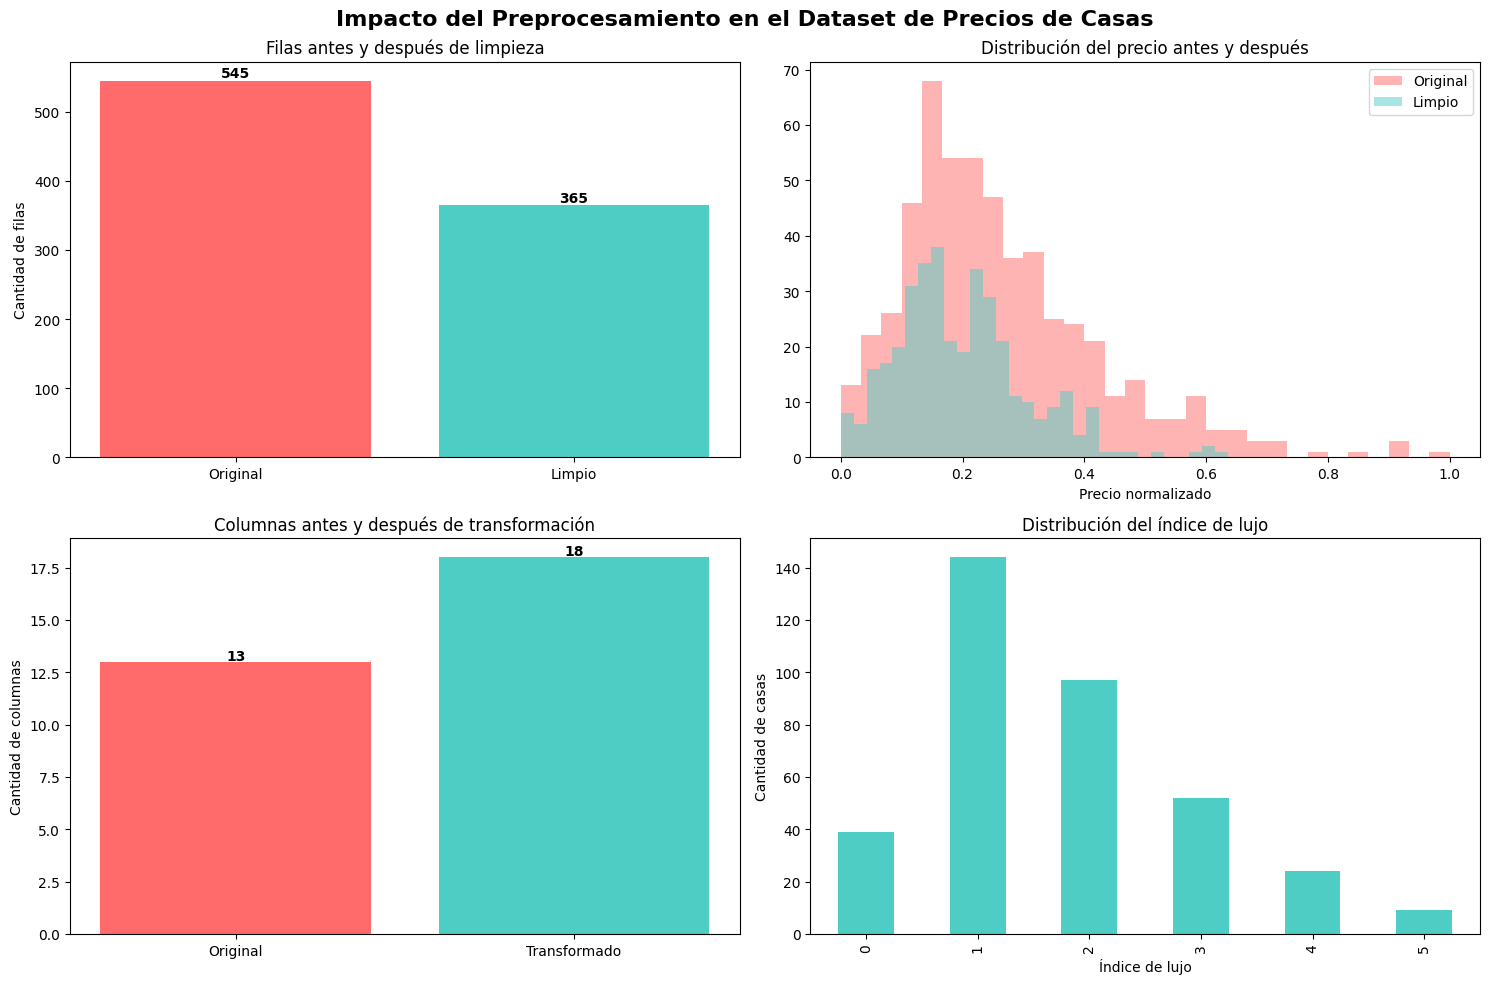

In [11]:
# ============================================
# PASO 11: VISUALIZACIÓN FINAL
# Comparamos el dataset antes y después del
# preprocesamiento para mostrar el impacto
# de las transformaciones aplicadas
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("Impacto del Preprocesamiento en el Dataset de Precios de Casas", 
             fontsize=16, fontweight='bold')

# Gráfico 1: Filas antes y después
axes[0, 0].bar(['Original', 'Limpio'], [545, 365], color=['#FF6B6B', '#4ECDC4'])
axes[0, 0].set_title("Filas antes y después de limpieza")
axes[0, 0].set_ylabel("Cantidad de filas")
for i, v in enumerate([545, 365]):
    axes[0, 0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Gráfico 2: Distribución del precio antes y después
axes[0, 1].hist(df['price'], bins=30, alpha=0.5, label='Original', color='#FF6B6B')
axes[0, 1].hist(df_limpio['price'], bins=30, alpha=0.5, label='Limpio', color='#4ECDC4')
axes[0, 1].set_title("Distribución del precio antes y después")
axes[0, 1].set_xlabel("Precio normalizado")
axes[0, 1].legend()

# Gráfico 3: Columnas antes y después
axes[1, 0].bar(['Original', 'Transformado'], [13, 18], color=['#FF6B6B', '#4ECDC4'])
axes[1, 0].set_title("Columnas antes y después de transformación")
axes[1, 0].set_ylabel("Cantidad de columnas")
for i, v in enumerate([13, 18]):
    axes[1, 0].text(i, v + 0.1, str(v), ha='center', fontweight='bold')

# Gráfico 4: Índice de lujo de las casas
df_limpio['indice_lujo'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1, 1], color='#4ECDC4')
axes[1, 1].set_title("Distribución del índice de lujo")
axes[1, 1].set_xlabel("Índice de lujo")
axes[1, 1].set_ylabel("Cantidad de casas")

plt.tight_layout()
plt.show()

In [12]:
# ============================================
# PASO 12: CREACIÓN DEL README
# Documentamos el flujo completo del proyecto
# ============================================

readme = """# Flujo Profesional de Datos - Housing Dataset

## Descripción
Proyecto de limpieza y transformación de datos del dataset de precios de casas.

## Dataset
- **Fuente:** Kaggle - Housing Prices Dataset
- **Filas originales:** 545
- **Columnas originales:** 13

## Flujo de trabajo
1. Carga y exploración del dataset
2. Codificación binaria de variables yes/no
3. One-Hot Encoding de furnishingstatus
4. Normalización con MinMaxScaler
5. Estandarización con StandardScaler
6. Detección de outliers con boxplots
7. Eliminación de outliers con método IQR
8. Feature Engineering (3 nuevas variables)
9. Guardado del dataset procesado

## Resultados
- **Filas después de limpieza:** 365
- **Columnas finales:** 18
- **Outliers eliminados:** 180

## Tecnologías usadas
- Python
- Pandas
- Scikit-learn
- Matplotlib
- Kedro
"""

with open("C:/Users/pc/repaso_ciencia/repaso-ciencia/README.md", "w", encoding="utf-8") as f:
    f.write(readme)

print("✅ README creado correctamente!")

✅ README creado correctamente!


In [15]:
df_limpio = df_limpio.copy()

# Ratio de precio por área
df_limpio['precio_por_area'] = df_limpio['price'] / df_limpio['area']

# Total de habitaciones
df_limpio['total_habitaciones'] = df_limpio['bedrooms'] + df_limpio['bathrooms']

# Índice de lujo (suma de comodidades)
df_limpio['indice_lujo'] = (df_limpio['mainroad'] + df_limpio['guestroom'] + 
                            df_limpio['basement'] + df_limpio['airconditioning'] + 
                            df_limpio['prefarea'])

print(df_limpio[['precio_por_area', 'total_habitaciones', 'indice_lujo']].head())

    precio_por_area  total_habitaciones  indice_lujo
15         2.128527                 0.6            2
20         3.302690                 0.4            2
22         1.357173                 0.4            4
27         1.159484                 0.4            1
40         1.574675                 0.4            4


In [16]:
df_limpio.to_csv("C:/Users/pc/repaso_ciencia/repaso-ciencia/data/02_intermediate/housing_limpio.csv", 
                 index=False)

print("✅ Dataset guardado correctamente!")
print(f"Filas: {df_limpio.shape[0]}")
print(f"Columnas: {df_limpio.shape[1]}")

✅ Dataset guardado correctamente!
Filas: 365
Columnas: 18
